### Get the comprehensive data profile of my dataset

In [4]:
import pandas as pd
import numpy as np

# 1. Load your dataset
df = pd.read_csv("./../data/raw/scraped_properties.csv")

# 2. Generate the Comprehensive Data Profile
profile = []
profile.append(f"=== GENERAL STRUCTURE ===")
profile.append(f"Total Rows: {df.shape[0]}")
profile.append(f"Total Columns: {df.shape[1]}\n")

profile.append(f"=== COLUMN DETAILS, TYPES, AND MISSING DATA ===")
missing_data = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

for col in df.columns:
    dtype = df[col].dtype
    null_count = missing_data[col]
    null_pct = missing_pct[col]
    unique_count = df[col].nunique()
    
    col_info = f"Column: '{col}' | Type: {dtype} | Missing: {null_count} ({null_pct:.2f}%) | Unique Values: {unique_count}"
    
    # If categorical, show top value distributions to check for class imbalance/bias
    if dtype == 'object' or unique_count < 10:
        top_vals = df[col].value_counts(dropna=False).head(5).to_dict()
        col_info += f"\n   -> Top Values/Distribution: {top_vals}"
    profile.append(col_info)

profile.append(f"\n=== NUMERICAL DISTRIBUTIONS (Descriptive Stats) ===")
# Capture summary statistics to detect skewness, scaling issues, and outliers
profile.append(df.describe(include=[np.number]).T.to_string())

profile.append(f"\n=== CORRELATION MATRIX (Top Linear Relationships) ===")
# Helps Claude identify multicollinearity issues for linear models
numerical_cols = df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 1:
    corr = df[numerical_cols].corr().round(2)
    profile.append(corr.to_string())
else:
    profile.append("Not enough numerical columns for correlation matrix.")

# 3. Save the profile to a text file
output_filename = "scraped_properties_ml_profile.txt"
with open(output_filename, "w", encoding="utf-8") as f:
    f.write("\n".join(profile))

print(f"Success! Upload '{output_filename}' to your Claude Project.")


Success! Upload 'scraped_properties_ml_profile.txt' to your Claude Project.


In [ ]:
import pandas as pd

hc_df = pd.read_csv("./../data/raw/half_cleaned_properties.csv")
scraped_df = pd.read_csv("./../data/raw/scraped_properties.csv")
hc_df.head()
scraped_df.head()

,province,type_property,property_id,subtype_property,postal_code,city,price,state_of_property,heating_type,sun_exposure,...,bathrooms,toilets,terrace,garden,garage,swimming_pool,flooding_area_type,distance_from_train_stations_by_foot,distance_from_elementary_school_by_foot,distance_from_high_school_by_foot
0,brussels,house,vbe35189,residence,1150,sint_pieters_woluwe,925000.0,to_be_renovated,fuel_oil,south_east,...,2,3,1,1,0,0,(information_not_available),4300.0,352.0,352.0
1,brussels,apartment,vbe35095,duplex,1000,brussels,395000.0,excellent,gas,not_specified,...,2,2,0,0,0,0,no_flooding_area,781.0,157.0,184.0
2,brussels,apartment,vbe35094,apartment,1210,sint_joost_ten_node,295000.0,normal,gas,not_specified,...,1,1,1,0,0,0,no_flooding_area,1100.0,173.0,237.0
3,brussels,apartment,vbe35040,apartment,1050,elsene,465000.0,fully_renovated,gas,not_specified,...,1,1,1,0,0,0,no_flooding_area,995.0,269.0,561.0
4,brussels,apartment,vbe34652,studio,1210,sint_joost_ten_node,150000.0,to_renovate,electricity,not_specified,...,1,0,1,0,0,0,(information_not_available),1200.0,197.0,133.0


In [ ]:
# Get the corr matrix wrt price
import pandas as pd
import numpy as np

df = pd.read_csv("./../data/raw/scraped_properties.csv")

# 2. Calculate correlation specifically with respect to the 'price' attribute
# .corrwith() computes pairwise correlation between a DataFrame's columns and a Series
# Pass numeric_only=True to skip text/categorical columns automatically
price_corr = df.corrwith(df['price'], numeric_only=True)

# 3. Convert to DataFrame and add an 'absolute_corr' column for accurate sorting
corr_df = pd.DataFrame(price_corr, columns=['Correlation_Score'])
corr_df['Absolute_Correlation'] = corr_df['Correlation_Score'].abs()

# 4. Sort from highest absolute correlation (strongest) to lowest (weakest)
# We drop 'price' itself so it doesn't show a perfect 1.0 correlation with itself
sorted_corr = corr_df.drop('price').sort_values(by='Absolute_Correlation', ascending=False)

# 5. Display the final result
print("Attributes ranked from Strongest to Weakest Correlation with 'price':\n")
print(sorted_corr[['Correlation_Score']])


Attributes ranked from Strongest to Weakest Correlation with 'price':

                                         Correlation_Score
bedrooms                                          0.563345
toilets                                           0.558739
bathrooms                                         0.554115
swimming_pool                                     0.472701
showers                                           0.457702
facades                                           0.251943
postal_code                                      -0.180081
garden                                            0.170042
terrace                                           0.124941
livable_surface                                   0.118136
veranda                                           0.108562
cellar                                            0.095652
distance_from_metro_by_foot                       0.091550
construction_year                                 0.071044
floors                                      

## Code to get visuals

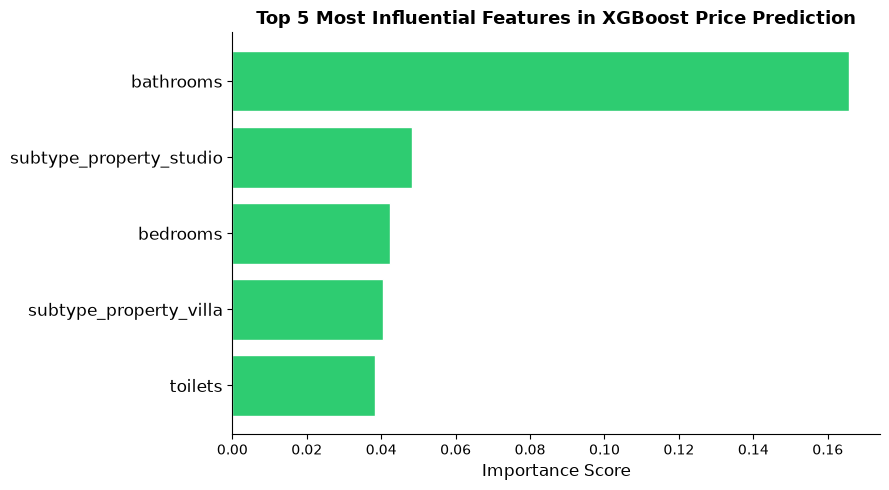

In [22]:
import matplotlib.pyplot as plt
import joblib
import numpy as np

model = joblib.load("./../models/xgboost.joblib")
xgb = model.named_steps["model"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = xgb.feature_importances_
indices = np.argsort(importances)[-5:]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(5), importances[indices], color="#2ecc71", edgecolor="white")
ax.set_yticks(range(5))
ax.set_yticklabels([feature_names[i].replace("cat__", "").replace("num__", "") for i in indices], fontsize=12)
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title("Top 5 Most Influential Features in XGBoost Price Prediction", fontsize=13, fontweight="bold", loc="center")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("./../assets/feature_importance.png", dpi=150)
plt.show()

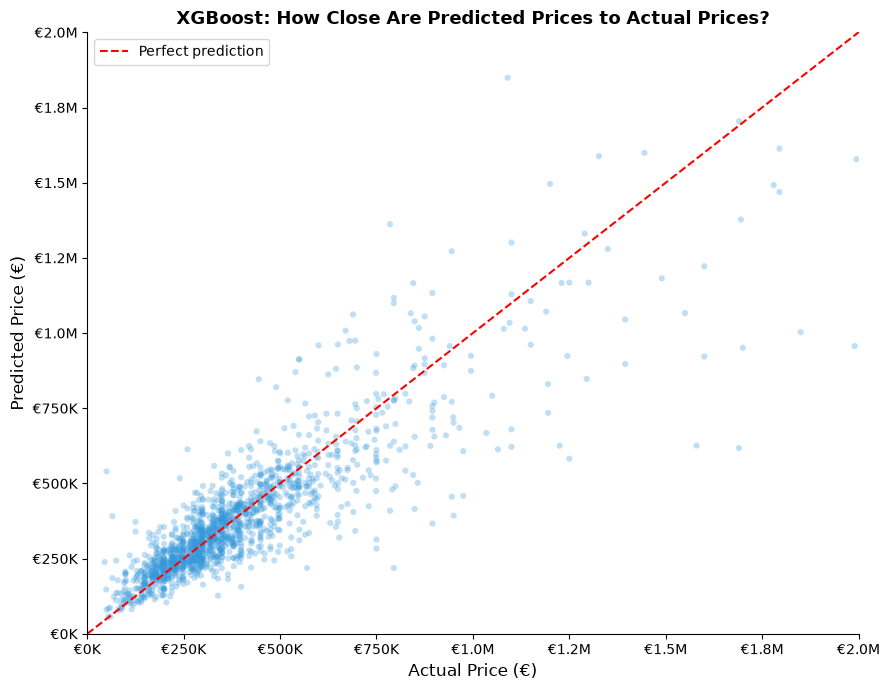

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
from sklearn.model_selection import train_test_split

model = joblib.load("./../models/xgboost.joblib")

# Load already cleaned CSV — no import needed
df = pd.read_csv("./../data/cleaned/properties_for_ml.csv")

_, test_df = train_test_split(df, test_size=0.2, random_state=42)

X_test  = test_df.drop(columns=["price"])
y_test  = np.log1p(test_df["price"])   # manually log-transform here

y_actual    = np.expm1(y_test)
y_predicted = np.expm1(model.predict(X_test))

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_actual, y_predicted, alpha=0.3, color="#3498db", edgecolors="none", s=20)
ax.plot([0, y_actual.max()], [0, y_actual.max()], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Price (€)", fontsize=12)
ax.set_ylabel("Predicted Price (€)", fontsize=12)
ax.set_title("XGBoost: How Close Are Predicted Prices to Actual Prices?", fontsize=13, fontweight="bold", loc="center")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M" if x >= 1e6 else f"€{x/1e3:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M" if x >= 1e6 else f"€{x/1e3:.0f}K"))
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 2_000_000)
ax.set_ylim(0, 2_000_000)
plt.tight_layout()
plt.savefig("./../assets/actual_vs_predicted.png", dpi=150)
plt.show()

In [21]:
pd.read_csv("./../data/cleaned/properties_for_ml.csv")["price"].describe()

count    7.727000e+03
mean     4.107936e+05
std      3.263985e+05
min      3.048000e+03
25%      2.390000e+05
50%      3.395000e+05
75%      4.790000e+05
max      6.450000e+06
Name: price, dtype: float64